In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f

Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 13:16:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Load and prepare the data


In [3]:
g_p_s = session.spark.read.parquet("../../../data/intermidiate_files/genes_therapeutic_areas")

In [4]:
combined_evidence = session.spark.read.parquet("../../../data/intermidiate_files/list_of_genes_32_categories")
combined_evidence.count()

82410

In [5]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|orphanet|
+---------------+--------+
only showing top 1 row



In [6]:
combined_evidence.groupBy("source").count().show(100)

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|            fusil_DL|  785|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|            fusil_CL|  415|
|            fusil_VP| 1862|
|            fusil_SV|  419|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|            fusil_VN|  321|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|           All genes|20083|
|       non_essential|  766|
|       lof_constr_Q4| 4520|
|       lof_constr_Q2| 4532|
|       lof_constr_Q3| 4519|
|       lof_co

In [7]:
gwas_genes = combined_evidence.filter(f.col("source") == "all_diseases").select("targetId").distinct()

In [8]:
# Create mapping dictionary
category_mapping = {
    "all_diseases": "GWAS",
    "cancer_ChEMBL": "Cancer ChEMBL",
    "gene_burden": "Gene-based analysis",
    "omim": "OMIM",
    "cancer_driver_gene": "Cancer Driver (COSMIC)",
    "withdrawn_drug": "Withdrawn Drug",
    "non_cancer_ChEMBL": "Non-Cancer ChEMBL",
    "essential_gene": "Essential Gene (DepMap)",
    "gwas_eQTL": "GWAS with eQTL evidence",
    "gwas_with_pav": "GWAS with PAV evidence",
    "liable_target": "Known safety events",
    "orphanet": "Orphanet",
    "ChEMBL": "ChEMBL",
    "dd_related": "DD panel (gene2phenotype)",
    "pharmacogene": "Pharmacogenetics - Toxicity",
    "trial_safety_concern": "Trial Safety",
    "mouse_ko_mortality": "Mouse KO Mortality",
    "All genes": "All protein-coding genes",
    "fusil_CL": "Cellular lethal (FUSIL)",
    "fusil_DL": "Developmental lethal (FUSIL)",
    "fusil_SV": "Subviable (FUSIL)",
    "fusil_VP": "Viable with phenotype (FUSIL)",
    "fusil_VN": "Viable with no phenotype (FUSIL)",
    "lof_constr_Q4": "Q4 LoF constraint",
    "lof_constr_Q3": "Q3 LoF constraint",
    "lof_constr_Q2": "Q2 LoF constraint",
    "lof_constr_Q1": "Q1 LoF constraint",
    "non_essential": "Non-essential Gene (DepMap)",
}

# Apply the mapping
from pyspark.sql.functions import col

combined_evidence = combined_evidence.replace(category_mapping, subset=["source"])

In [9]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|   Subviable (FUSIL)|  419|
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
|Non-essential Gen...|  766|
|Viable with pheno...| 1862|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Viable with no ph...|  321|
+--------------------+-----+
only showing top 20 rows



In [10]:
g_p_s = g_p_s.withColumnRenamed("geneId", "targetId")
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|       targetId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

25/11/21 13:17:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [11]:
combined_evidence = (
    combined_evidence.join(g_p_s.select("targetId", "uniqueDiseases", "pathwayCount"), on="targetId", how="left")
    .fillna(0, subset=["uniqueDiseases", "pathwayCount"])
    .cache()
)

combined_evidence.count()

82410

In [12]:
combined_evidence.show(1)

+---------------+--------+--------------+------------+
|       targetId|  source|uniqueDiseases|pathwayCount|
+---------------+--------+--------------+------------+
|ENSG00000121075|Orphanet|             2|           0|
+---------------+--------+--------------+------------+
only showing top 1 row



In [13]:
combined_evidence_pd = combined_evidence.toPandas()

In [14]:
combined_evidence_pd

,targetId,source,uniqueDiseases,pathwayCount
0,ENSG00000121075,Orphanet,2,0
1,ENSG00000149970,Orphanet,7,7
2,ENSG00000111837,Orphanet,3,0
3,ENSG00000184156,Orphanet,2,2
4,ENSG00000135249,Orphanet,0,0
...,...,...,...,...
82405,ENSG00000286140,Q1 LoF constraint,0,0
82406,ENSG00000288684,Q2 LoF constraint,0,0
82407,ENSG00000288841,Q4 LoF constraint,0,0
82408,ENSG00000288914,Q1 LoF constraint,0,0


In [15]:
disease_genes = [row.targetId for row in gwas_genes.collect()]

In [16]:
len(disease_genes)

8285

# Select categories to test


In [17]:
categories_for_plot = [
    "Gene-based analysis",
    "OMIM",
    "Cancer Driver (COSMIC)",
    "Withdrawn Drug",
    "Essential Gene (DepMap)",
    "Known safety events",
    "Orphanet",
    "ChEMBL",
    "DD panel (gene2phenotype)",
    "Trial Safety",
    "Mouse KO Mortality",
    "Cellular lethal (FUSIL)",
    "Developmental lethal (FUSIL)",
    "Subviable (FUSIL)",
    "Viable with phenotype (FUSIL)",
    "Viable with no phenotype (FUSIL)",
    "Q4 LoF constraint",
    "Q1 LoF constraint",
    "GWAS",
    "Non-essential Gene (DepMap)",
]

In [18]:
comb_evid_plot = combined_evidence_pd[combined_evidence_pd["source"].isin(categories_for_plot)]

# Test for singificant diffrence of gPS between each category vs disease GWAS genes


In [19]:
import numpy as np
import pandas as pd

# build disease set (same as before)
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare deduplicated df (one row per source,targetId)
df = (
    comb_evid_plot[["source", "targetId", "uniqueDiseases"]]
    .dropna(subset=["source", "targetId", "uniqueDiseases"])
    .drop_duplicates(["source", "targetId"])
    .copy()
)

# restrict to genes in disease_set (overlap only)
df_overlap = df[df["targetId"].isin(disease_set)].copy()

# mapping targetId -> measurement (one value per target)
vals_by_target = df_overlap.drop_duplicates("targetId").set_index("targetId")["uniqueDiseases"].dropna()
universe_vals = vals_by_target.values  # x in your example

# ensure GWAS present (name used in notebook = 'GWAS')
if "GWAS" not in df_overlap["source"].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# permutation test parameters
n_perm = 20000
rng = np.random.default_rng(42)

results = []
sources = sorted(df_overlap["source"].unique())
for src in sources:
    if src == "GWAS":
        continue

    # ids in this source (within the overlap)
    subset_ids = np.unique(df_overlap.loc[df_overlap["source"] == src, "targetId"].values)
    subset_vals = vals_by_target.reindex(subset_ids).dropna().values

    n_sub = len(subset_vals)
    n_univ = len(universe_vals)

    if n_sub < 1 or n_sub > n_univ:
        # cannot perform permutation
        results.append(
            {
                "source": src,
                "n_subset": n_sub,
                "mean_subset": np.nan,
                "mean_universe": np.nan,
                "obs_diff": np.nan,
                "p_value_perm": np.nan,
                "perm_mean": np.nan,
                "perm_std": np.nan,
            }
        )
        continue

    mean_univ = universe_vals.mean()
    mean_sub = subset_vals.mean()
    obs_diff = mean_sub - mean_univ

    # perform permutations: sample subsets of size n_sub from universe_vals without replacement
    perm_diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        sample = rng.choice(universe_vals, size=n_sub, replace=False)
        perm_diffs[i] = sample.mean() - mean_univ

    # two-sided empirical p-value
    p_val = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

    results.append(
        {
            "source": src,
            "n_subset": n_sub,
            "n_universe": n_univ,
            "mean_subset": mean_sub,
            "mean_universe": mean_univ,
            "obs_diff": obs_diff,
            "p_value_perm": p_val,
            "perm_mean": perm_diffs.mean(),
            "perm_std": perm_diffs.std(ddof=1),
        }
    )

res_df = pd.DataFrame(results).sort_values("p_value_perm", na_position="last").reset_index(drop=True)

In [20]:
# Benjamini-Hochberg FDR on permutation p-values (fixed)
p = res_df["p_value_perm"].to_numpy(dtype=float)
mask = ~np.isnan(p)
adj_full = np.full_like(p, np.nan, dtype=float)

if mask.sum() > 0:
    pvals = p[mask]
    m = pvals.size
    order = np.argsort(pvals)  # indices that sort pvals ascending
    sorted_p = pvals[order]
    ranks = np.arange(1, m + 1)
    q = sorted_p * m / ranks  # raw BH adjusted (not yet monotonic)
    # enforce monotonicity: take cumulative minimum from largest rank to smallest
    q_adj = np.minimum.accumulate(q[::-1])[::-1]
    q_adj = np.clip(q_adj, 0, 1)
    # map adjusted back to the masked original order
    adj_masked = np.empty_like(q_adj)
    adj_masked[order] = q_adj
    adj_full[mask] = adj_masked

res_df["p_adj_bh"] = adj_full

In [21]:
res_df

,source,n_subset,n_universe,mean_subset,mean_universe,obs_diff,p_value_perm,perm_mean,perm_std,p_adj_bh
0,Cancer Driver (COSMIC),253,8285,9.541502,4.448763,5.092739,0.00000,-0.001178,0.410618,0.000000
1,Trial Safety,245,8285,7.297959,4.448763,2.849196,0.00000,-0.001124,0.416704,0.000000
2,ChEMBL,624,8285,6.126603,4.448763,1.677840,0.00000,0.000340,0.256425,0.000000
3,DD panel (gene2phenotype),494,8285,7.301619,4.448763,2.852857,0.00000,-0.002135,0.289787,0.000000
4,Gene-based analysis,339,8285,7.466077,4.448763,3.017314,0.00000,-0.002166,0.352936,0.000000
5,Q4 LoF constraint,2563,8285,5.590324,4.448763,1.141561,0.00000,-0.000277,0.108725,0.000000
6,Mouse KO Mortality,591,8285,7.397631,4.448763,2.948868,0.00000,0.003403,0.263263,0.000000
7,OMIM,2158,8285,6.041705,4.448763,1.592942,0.00000,0.000609,0.122753,0.000000
8,Orphanet,1939,8285,5.759670,4.448763,1.310907,0.00000,-0.001676,0.132065,0.000000
9,Developmental lethal (FUSIL),399,8285,5.689223,4.448763,1.240460,0.00045,0.001239,0.325396,0.000855


# Plot


In [ ]:
# Python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ensure disease_genes set exists
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# keep relevant columns and deduplicate per source,targetId
df = comb_evid_plot[["source", "targetId", "uniqueDiseases"]].dropna(subset=["source", "targetId"])
df = df.drop_duplicates(["source", "targetId"]).copy()

# totals per category
totals = df.groupby("source").agg(N_total=("targetId", "nunique")).reset_index()

# overlap rows and stats (mean, std, count)
df["in_disease"] = df["targetId"].isin(disease_set)
overlap = (
    df[df["in_disease"]]
    .groupby("source")
    .agg(
        N_overlap=("targetId", "nunique"),
        mean_uniqueDiseases=("uniqueDiseases", "mean"),
        std_uniqueDiseases=("uniqueDiseases", "std"),
        n=("uniqueDiseases", "count"),
    )
    .reset_index()
)

# merge and compute SE & 95% CI
stats = totals.merge(overlap, on="source", how="left").fillna(
    {"N_overlap": 0, "mean_uniqueDiseases": np.nan, "std_uniqueDiseases": np.nan, "n": 0}
)
stats["se"] = stats["std_uniqueDiseases"] / np.sqrt(stats["n"].replace(0, np.nan))
stats["ci95"] = 1.96 * stats["se"]

# add formatted label with percent and counts
stats["pct"] = 100 * stats["N_overlap"] / stats["N_total"]
stats["label"] = stats.apply(
    # lambda r: f"{r['source']} ({r['pct']:.1f}%/{int(r['N_overlap'])}/{int(r['N_total'])})", axis=1
    lambda r: f"{r['source']} ({int(r['N_total'])}/{r['pct']:.1f}%)",
    axis=1,
)

# order by mean desc (NaN go last)
stats_sorted = stats.sort_values("mean_uniqueDiseases", ascending=False, na_position="last").reset_index(drop=True)

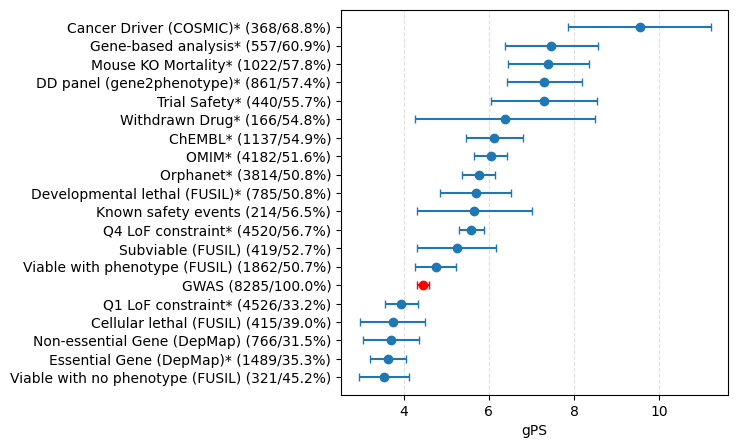

In [31]:
import matplotlib.patches as mpatches

# determine significant sources (BH-adjusted p <= 0.05) — keep robust if res_df missing
if "res_df" in globals():
    sig_sources = set(res_df.loc[res_df["p_adj_bh"] <= 0.05, "source"].dropna().astype(str))
else:
    sig_sources = set()


# add '*' to the category name in the label if significant
def add_star_to_label(label: str, source: str) -> str:
    try:
        s = str(source)
        if s in sig_sources:
            return label.replace(s, f"{s}*")
    except Exception:
        pass
    return label


stats_sorted["label"] = stats_sorted.apply(lambda r: add_star_to_label(r["label"], r["source"]), axis=1)

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted["label"])
ax.invert_yaxis()
ax.set_xlabel("gPS")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row["mean_uniqueDiseases"]):
        continue
    color = "red" if str(row["source"]) == "GWAS" else "C0"
    ax.errorbar(row["mean_uniqueDiseases"], i, xerr=row["ci95"], fmt="o", color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted["mean_uniqueDiseases"].isna()
if no_mask.any():
    ax.scatter([0] * no_mask.sum(), y[no_mask], marker="x", color="gray", alpha=0.6, label="no overlap")

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color="red", label="GWAS")
other_patch = mpatches.Patch(color="C0", label="Other sources")
# ax.legend(handles=[gw_patch, other_patch], loc='lower right')
# ...existing code...

In [ ]:
stats_sorted["source"]

0               Cancer Driver (COSMIC)
1                  Gene-based analysis
2                   Mouse KO Mortality
3            DD panel (gene2phenotype)
4                         Trial Safety
5                       Withdrawn Drug
6                               ChEMBL
7                                 OMIM
8                             Orphanet
9         Developmental lethal (FUSIL)
10                 Known safety events
11                   Q4 LoF constraint
12                   Subviable (FUSIL)
13       Viable with phenotype (FUSIL)
14                                GWAS
15                   Q1 LoF constraint
16             Cellular lethal (FUSIL)
17         Non-essential Gene (DepMap)
18             Essential Gene (DepMap)
19    Viable with no phenotype (FUSIL)
Name: source, dtype: object